# Evaluate SMB Delphi-style model

This notebook is a **template** for evaluating the SMB event model in the same spirit as the Delphi evaluation notebook:
- dataset sanity checks (format, sorting, token distributions)
- incidence curves over firm age (e.g., exits / distress events)
- next-event / time-to-event calibration checks
- optional model-based scoring (if you provide a trained checkpoint)

## Expected inputs (from your generated artifacts)
- `smb_train_v2.npy`, `smb_val_v2.npy`, `smb_test_v2.npy` (each: uint32 array with columns `[firm_id, firm_age_days, token_id]`)
- `smb_event_vocabulary_with_thresholds_and_index_v2.csv`
- optionally a trained model checkpoint (path depends on your repo)

> Note: If your repository includes an `evaluate_delphy.ipynb`, you can upload it and we can mirror its plots and metrics more closely. This notebook follows the **same evaluation ideas**, but is SMB-focused.


In [4]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("/Users/uzokirov/Development/Thirdparty/LLM/Delphi/data/smb_synthetic_data")

VOCAB_CSV = DATA_DIR / "smb_event_vocabulary_with_thresholds_and_index_v2.csv"
TRAIN_NPY = DATA_DIR / "smb_train_v2.npy"
VAL_NPY   = DATA_DIR / "smb_val_v2.npy"
TEST_NPY  = DATA_DIR / "smb_test_v2.npy"

assert VOCAB_CSV.exists(), f"Missing {VOCAB_CSV}"
assert TRAIN_NPY.exists(), f"Missing {TRAIN_NPY}"
assert VAL_NPY.exists(), f"Missing {VAL_NPY}"
assert TEST_NPY.exists(), f"Missing {TEST_NPY}"

vocab = pd.read_csv(VOCAB_CSV)
vocab.head()

,index,code,meaning,recommended_threshold_formula,index_old
0,0,PAD,Padding token for sequence alignment,Technical padding only; not emitted from data.,58
1,1,NO_EVENT,No significant business event observed,"Insert at fixed cadence (e.g., monthly or quar...",57
2,2,EXIT_BANKRUPTCY,Formal bankruptcy filing or court-supervised i...,Triggered by formal bankruptcy/insolvency fili...,0
3,3,EXIT_INSOLVENCY_NO_FILING,Business becomes insolvent without formal bank...,Triggered when business ceases operations with...,1
4,4,EXIT_FORCED_CLOSURE,"Business forced to close by creditors, authori...",Triggered by documented forced closure event (...,2


In [5]:
# Basic vocab sanity checks
code_to_id = dict(zip(vocab["code"].astype(str), vocab["index"].astype(int)))

print("vocab_size:", vocab["index"].max() + 1)
print("PAD id:", code_to_id.get("PAD"))
print("NO_EVENT id:", code_to_id.get("NO_EVENT"))

assert code_to_id["PAD"] == 0, "Expected PAD=0"
assert code_to_id["NO_EVENT"] == 1, "Expected NO_EVENT=1"

# Input-only tokens (ignored for gradients)
input_prefixes = ("SECTOR_", "SIZE_", "FORM_", "REGION_")
input_only = vocab[vocab["code"].astype(str).str.startswith(input_prefixes)].copy()
print("Input-only tokens:", len(input_only))

# Exits
exit_tokens = vocab[vocab["code"].astype(str).str.startswith("EXIT_")].copy()
print("Exit tokens:", len(exit_tokens))
exit_tokens[["index","code","meaning"]].sort_values("index")

vocab_size: 78
PAD id: 0
NO_EVENT id: 1
Input-only tokens: 19
Exit tokens: 7


,index,code,meaning
2,2,EXIT_BANKRUPTCY,Formal bankruptcy filing or court-supervised i...
3,3,EXIT_INSOLVENCY_NO_FILING,Business becomes insolvent without formal bank...
4,4,EXIT_FORCED_CLOSURE,"Business forced to close by creditors, authori..."
5,5,EXIT_DISTRESSED_RESTRUCTURE,Distressed debt or operational restructuring
6,6,EXIT_VOLUNTARY_CLOSURE,Owner voluntarily closes the business
7,7,EXIT_ACQUIRED_SMALL,Business acquired by another small or private ...
8,8,EXIT_DATA_CENSORING,Observation ends without known exit outcome


In [6]:
def load_events(path: Path) -> np.ndarray:
    arr = np.load(path)
    if arr.dtype != np.uint32:
        arr = arr.astype(np.uint32, copy=False)
    assert arr.ndim == 2 and arr.shape[1] == 3, f"Expected Nx3 array, got {arr.shape}"
    return arr

train = load_events(TRAIN_NPY)
val   = load_events(VAL_NPY)
test  = load_events(TEST_NPY)

train[:5], train.dtype, train.shape

(array([[ 1,  0, 63],
        [ 1,  0, 69],
        [ 1,  0, 74],
        [ 1,  0, 77],
        [ 1, 30,  1]], dtype=uint32),
 dtype('uint32'),
 (337685, 3))

In [7]:
def check_sorted(arr: np.ndarray, name: str):
    # Check non-decreasing by (firm_id, age_days), and token_id within same age
    firm = arr[:,0].astype(np.uint64)
    age  = arr[:,1].astype(np.uint64)
    tok  = arr[:,2].astype(np.uint64)
    
    # lexicographic check: firm nondecreasing; if firm equal then age nondecreasing; if age equal then tok nondecreasing
    ok = True
    for i in range(1, len(arr)):
        if firm[i] < firm[i-1]:
            ok = False; break
        if firm[i] == firm[i-1] and age[i] < age[i-1]:
            ok = False; break
        if firm[i] == firm[i-1] and age[i] == age[i-1] and tok[i] < tok[i-1]:
            ok = False; break
    print(f"{name}: sorted={ok} rows={len(arr)} firms={len(np.unique(arr[:,0]))}")
    return ok

check_sorted(train, "train")
check_sorted(val, "val")
check_sorted(test, "test")

train: sorted=True rows=337685 firms=2398
val: sorted=True rows=43858 firms=301
test: sorted=True rows=42693 firms=301


True

In [8]:
# Token frequency in each split
id_to_code = dict(zip(vocab["index"].astype(int), vocab["code"].astype(str)))

def token_counts(arr: np.ndarray) -> pd.DataFrame:
    counts = pd.Series(arr[:,2]).value_counts().sort_index()
    df = pd.DataFrame({"token_id": counts.index.astype(int), "count": counts.values.astype(int)})
    df["code"] = df["token_id"].map(id_to_code)
    return df.sort_values("count", ascending=False)

train_counts = token_counts(train)
val_counts   = token_counts(val)
test_counts  = token_counts(test)

train_counts.head(15)

,token_id,count,code
0,1,117139,NO_EVENT
15,16,10690,CFO_NEG_2_CONSEC
32,33,10614,BANK_CREDIT_LINE_FROZEN
46,47,10583,PAYROLL_DELAYED
37,38,10549,PAY_DPD_30PLUS
8,9,10535,CASH_BALANCE_ZERO
9,10,10525,CASH_RUNWAY_LT_1M
38,39,10511,PAY_DPD_60PLUS
31,32,10471,BANK_OVERDRAFT_LIMIT_BREACH
14,15,10469,CFO_NEG_1_PERIOD


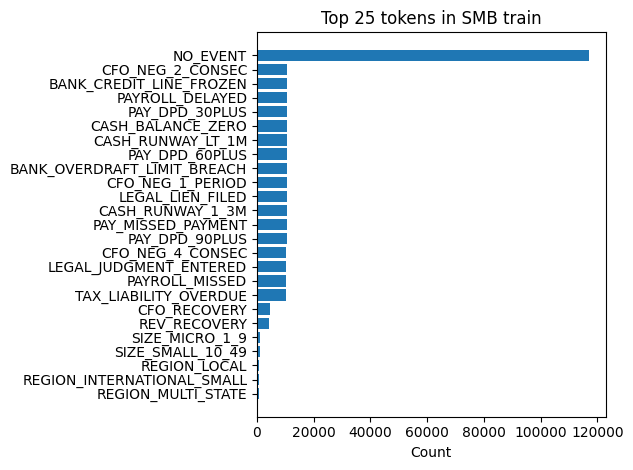

In [9]:
# Plot top tokens (train)
topn = 25
df = train_counts.head(topn).iloc[::-1]  # reverse for horizontal bar
plt.figure()
plt.barh(df["code"], df["count"])
plt.title(f"Top {topn} tokens in SMB train")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

## Incidence curves over firm age

Below we compute *incidence* (event rate) as a function of firm age (in years) for:
- exit outcomes (bankruptcy, insolvency without filing, etc.)
- selected distress indicators (e.g., `CASH_RUNWAY_LT_1M`, `PAY_DPD_90PLUS`)

This mirrors the Delphi-style evaluation of age-specific incidence curves.


In [10]:
def to_years(days: np.ndarray) -> np.ndarray:
    return days.astype(np.float64) / 365.0

def incidence_over_age(arr: np.ndarray, token_id: int, bin_years: float = 0.5, max_years: float = 8.0):
    # For each firm, count whether token appears in a bin; normalize by firms at risk at start of bin.
    df = pd.DataFrame(arr, columns=["firm_id","age_days","token_id"])
    df["age_years"] = df["age_days"] / 365.0
    
    bins = np.arange(0, max_years + bin_years, bin_years)
    labels = (bins[:-1] + bins[1:]) / 2.0
    
    # firms present (at least one record) imply at-risk from age 0 until their last observation
    last_age = df.groupby("firm_id")["age_years"].max()
    
    # occurrences of the token per firm per bin (binary)
    tok = df[df["token_id"] == token_id].copy()
    tok["bin"] = pd.cut(tok["age_years"], bins=bins, right=False, labels=False)
    tok = tok.dropna(subset=["bin"])
    occ = tok.groupby(["firm_id","bin"]).size().reset_index(name="n")
    occ["n"] = 1
    
    # at-risk firms per bin = firms with last_age >= bin_start
    rates = []
    for b in range(len(bins)-1):
        start = bins[b]
        at_risk = (last_age >= start).sum()
        events = occ[occ["bin"]==b]["n"].sum()
        rate = events / at_risk if at_risk > 0 else np.nan
        rates.append((labels[b], at_risk, events, rate))
    return pd.DataFrame(rates, columns=["age_years_mid","at_risk_firms","event_firms","incidence_per_bin"])

# Choose a few tokens to plot
tokens_to_plot = [
    "EXIT_BANKRUPTCY",
    "EXIT_INSOLVENCY_NO_FILING",
    "CASH_RUNWAY_LT_1M",
    "PAY_DPD_90PLUS",
]

for code in tokens_to_plot:
    if code in code_to_id:
        print(code, "->", code_to_id[code])

EXIT_BANKRUPTCY -> 2
EXIT_INSOLVENCY_NO_FILING -> 3
CASH_RUNWAY_LT_1M -> 10
PAY_DPD_90PLUS -> 40


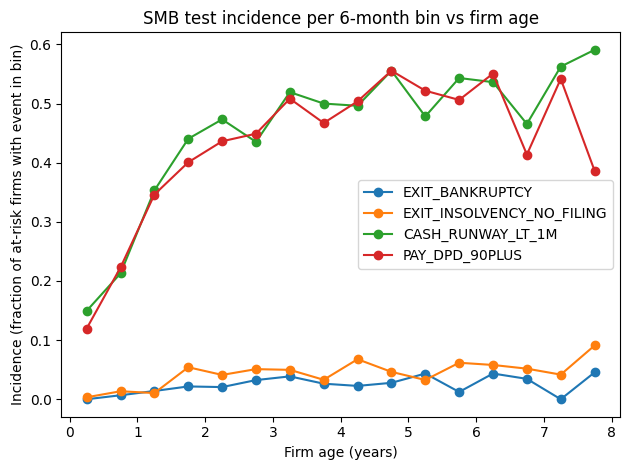

In [11]:
plt.figure()
for code in tokens_to_plot:
    if code not in code_to_id:
        continue
    tid = code_to_id[code]
    inc = incidence_over_age(test, tid, bin_years=0.5, max_years=8.0)
    plt.plot(inc["age_years_mid"], inc["incidence_per_bin"], marker="o", label=code)

plt.title("SMB test incidence per 6-month bin vs firm age")
plt.xlabel("Firm age (years)")
plt.ylabel("Incidence (fraction of at-risk firms with event in bin)")
plt.legend()
plt.tight_layout()
plt.show()

## Exit composition (competing outcomes)

Compute distribution of *first exit token* per firm in the test set.


In [12]:
exit_ids = set(exit_tokens["index"].astype(int).tolist())

def first_exit_per_firm(arr: np.ndarray) -> pd.DataFrame:
    df = pd.DataFrame(arr, columns=["firm_id","age_days","token_id"])
    df = df[df["token_id"].isin(exit_ids)].copy()
    if df.empty:
        return pd.DataFrame(columns=["exit_token_id","count","code"])
    # first exit by age
    df = df.sort_values(["firm_id","age_days","token_id"], kind="mergesort")
    first = df.groupby("firm_id").first().reset_index()
    out = first["token_id"].value_counts().reset_index()
    out.columns = ["exit_token_id","count"]
    out["code"] = out["exit_token_id"].map(id_to_code)
    return out.sort_values("count", ascending=False)

exit_dist = first_exit_per_firm(test)
exit_dist

,exit_token_id,count,code
0,3,93,EXIT_INSOLVENCY_NO_FILING
1,2,53,EXIT_BANKRUPTCY
2,6,46,EXIT_VOLUNTARY_CLOSURE
3,5,30,EXIT_DISTRESSED_RESTRUCTURE
4,4,24,EXIT_FORCED_CLOSURE
5,7,15,EXIT_ACQUIRED_SMALL
6,8,7,EXIT_DATA_CENSORING


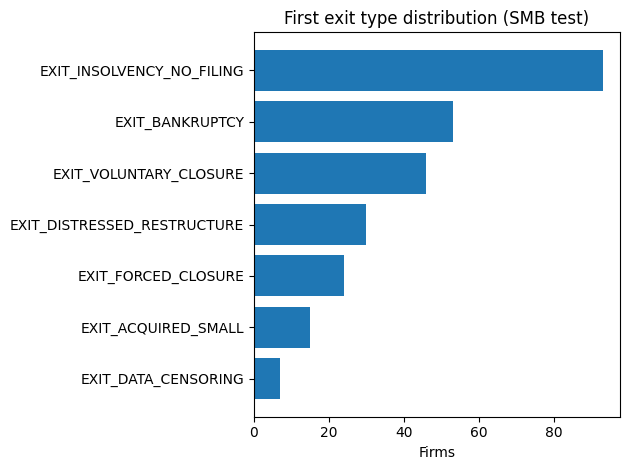

In [13]:
if not exit_dist.empty:
    plt.figure()
    df = exit_dist.iloc[::-1]
    plt.barh(df["code"], df["count"])
    plt.title("First exit type distribution (SMB test)")
    plt.xlabel("Firms")
    plt.tight_layout()
    plt.show()
else:
    print("No exits found in test set (unexpected for this synthetic cohort).")

## (Optional) Model-based evaluation

If you have a trained checkpoint, you can add model scoring here:
- next-event cross-entropy on val/test
- time-to-next-event calibration (compare predicted mean time vs observed)
- horizon probability of `EXIT_BANKRUPTCY` within 6/12 months

Because repo layouts differ, the code below is **guarded** with try/except.  
Set `CKPT_PATH` to your checkpoint and adjust imports to your training code.


In [ ]:
CKPT_PATH = None  # e.g., DATA_DIR / "SMB_Delphi" / "ckpt.pt"
print("Set CKPT_PATH to run model-based evaluation.")

In [ ]:
# Example scaffold (edit to match your repo)
# This is intentionally minimal and may need slight tweaks for your codebase.

import importlib

def try_load_model(ckpt_path):
    import torch
    if ckpt_path is None:
        return None
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(ckpt_path)
    
    # Try common patterns: model.py exposing Delphi / DelphiConfig
    try:
        model_mod = importlib.import_module("model")
        DelphiConfig = getattr(model_mod, "DelphiConfig", None)
        Delphi = getattr(model_mod, "Delphi", None)
        if DelphiConfig is None or Delphi is None:
            raise AttributeError("model.py does not expose DelphiConfig/Delphi")
    except Exception as e:
        print("Could not import Delphi model from model.py:", e)
        return None
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    checkpoint = torch.load(ckpt_path, map_location=device)
    cfg = DelphiConfig(**checkpoint.get("config", {})) if "config" in checkpoint else DelphiConfig()
    m = Delphi(cfg).to(device)
    m.load_state_dict(checkpoint["model"] if "model" in checkpoint else checkpoint["model_state_dict"])
    m.eval()
    return m, cfg, device

# Uncomment when you have a checkpoint:
# model_bundle = try_load_model(CKPT_PATH)
# model_bundle

## Next steps

If you upload your repo’s `evaluate_delphy.ipynb` (or paste its key cells), I can:
- match its metric definitions exactly
- replicate the same plots with SMB tokens
- wire the notebook directly into your checkpoint naming conventions and dataloader
